# LLM-as-a-Judge Scene Comparison Grid

Builds a comparison grid for qualitative (LLM-judge) evaluation.

**Rows** (4 methods):
- Random — all steps chosen randomly (no compatibility signal)
- ResNet-18 (ImageNet) — cosine similarity in pretrained ImageNet feature space
- EfficientNet-B3 (ImageNet) — same, with a deeper backbone
- Fine-tuned (ours) — triplet-trained SiameseResnet18 embeddings + colour histogram (0.8 / 0.2)

**Columns**: furniture chain steps in the order used by the app.

All four methods share the same anchor item (step 1) so the LLM can judge
purely how compatible the subsequent picks are.

Saved to `data/thesis_figures/llm_judge/` at 300 DPI.

In [1]:
import sys
import json
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE_DIR = next(
    p for p in [Path().cwd()] + list(Path().cwd().parents)
    if (p / "src" / "retrieval" / "retrieval_logic.py").exists()
)
sys.path.insert(0, str(BASE_DIR / "src" / "retrieval"))
from retrieval_logic import FurnitureRetriever, CATEGORY_CHAINS

OUT_DIR = BASE_DIR / "data" / "thesis_figures" / "llm_judge"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

plt.rcParams.update({
    "font.family":       "DejaVu Serif",
    "font.size":         9,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
})

STEP_LABELS = {
    "bed":          "Bed",
    "sofa":         "Sofa",
    "small_storage":"Storage (S)",
    "large_storage":"Storage (L)",
    "nightstand":   "Nightstand",
    "table":        "Table",
    "chair_stool":  "Chair/Stool",
    "curtain":      "Curtain",
}
ROOM_LABELS = {"bedrooms": "Bedrooms", "living_rooms": "Living Rooms"}

METHOD_COLORS = {
    "Random":                        "#546E7A",
    "ResNet-18\n(ImageNet)":         "#E65100",
    "EfficientNet-B3\n(ImageNet)":   "#6A1B9A",
    "Fine-tuned\n(ours)":            "#1B5E20",
}

print(f"Device  : {DEVICE}")
print(f"BASE_DIR: {BASE_DIR}")
print(f"Output  : {OUT_DIR}")

Device  : cuda
BASE_DIR: d:\Programing\thesis_v2_v3
Output  : d:\Programing\thesis_v2_v3\data\thesis_figures\llm_judge


In [2]:
def extract_features(backbone, paths, batch_size=32):
    """Run backbone over all paths; return L2-normalised feature matrix (N, D)."""
    backbone = backbone.to(DEVICE).eval()
    all_feats = []
    with torch.no_grad():
        for start in range(0, len(paths), batch_size):
            batch_paths = paths[start : start + batch_size]
            imgs = []
            for p in batch_paths:
                try:
                    imgs.append(BASE_TRANSFORM(Image.open(p).convert("RGB")))
                except Exception:
                    imgs.append(torch.zeros(3, 224, 224))
            batch = torch.stack(imgs).to(DEVICE)
            feats = backbone(batch)
            feats = torch.flatten(feats, 1)
            feats = nn.functional.normalize(feats, p=2, dim=1)
            all_feats.append(feats.cpu().numpy())
            done = min(start + batch_size, len(paths))
            print(f"  {done}/{len(paths)}", end="\r")
    print()
    return np.vstack(all_feats)

In [3]:
class BaselineRetriever:
    """
    Drop-in replacement for FurnitureRetriever that uses raw pretrained
    backbone features instead of fine-tuned embeddings.
    Colour histogram is not used (embedding-only scoring).
    """

    def __init__(self, room: str, backbone: nn.Module):
        self.room = room
        self._image_root = BASE_DIR / "data" / "total" / room
        retrieval_dir = BASE_DIR / "data" / "retrieval_data" / room

        with open(retrieval_dir / "retrieval_index.json") as f:
            raw = json.load(f)
        self._index: dict[int, dict] = {int(k): v for k, v in raw.items()}

        rows_sorted = sorted(self._index.keys())
        paths = [
            self._image_root / self._index[r]["category"] / self._index[r]["image_name"]
            for r in rows_sorted
        ]

        print(f"Extracting features for {len(paths)} items ({room})...")
        raw_embs = extract_features(backbone, paths)

        max_row = max(rows_sorted)
        self._embeddings = np.zeros((max_row + 1, raw_embs.shape[1]), dtype=np.float32)
        for i, r in enumerate(rows_sorted):
            self._embeddings[r] = raw_embs[i]

        self._category_rows: dict[str, list[int]] = defaultdict(list)
        self._id_to_row: dict[str, int] = {}
        for row, meta in self._index.items():
            self._category_rows[meta["category"]].append(row)
            self._id_to_row[meta["furniture_id"]] = row

        print(f"  Done — {len(self._index)} items, {len(self._category_rows)} categories")

    def get_random(self, category: str, n: int = 1) -> list[dict]:
        rows = self._category_rows.get(category, [])
        chosen = random.sample(rows, min(n, len(rows)))
        return [self._to_dict(r) for r in chosen]

    def get_compatible(
        self, selected: list[dict], target_category: str,
        top_k: int = 1, weights=None, exclude_ids=None,
    ) -> list[dict]:
        if not selected:
            return self.get_random(target_category, n=top_k)

        n_sel = len(selected)
        if weights is None:
            weights = (
                [0.3 + 0.7 * (i / (n_sel - 1)) for i in range(n_sel)]
                if n_sel > 1 else [1.0]
            )
        total_w = sum(weights)

        candidate_rows = list(self._category_rows.get(target_category, []))
        if exclude_ids:
            candidate_rows = [
                r for r in candidate_rows
                if self._index[r]["furniture_id"] not in exclude_ids
            ]
        if not candidate_rows:
            return []

        cand_arr  = np.array(candidate_rows)
        cand_embs = self._embeddings[cand_arr]
        scores    = np.zeros(len(candidate_rows), dtype=np.float32)

        for item, w in zip(selected, weights):
            row = self._id_to_row.get(item["furniture_id"])
            if row is not None:
                scores += w * (cand_embs @ self._embeddings[row])
        scores /= total_w

        k         = min(top_k, len(scores))
        top_local = np.argpartition(scores, -k)[-k:]
        top_local = top_local[np.argsort(scores[top_local])[::-1]]

        return [self._to_dict(candidate_rows[i], score=float(scores[i])) for i in top_local]

    def _to_dict(self, row: int, score: float = 0.0) -> dict:
        meta = self._index[row]
        return {
            "furniture_id": meta["furniture_id"],
            "category":     meta["category"],
            "image_path":   str(self._image_root / meta["category"] / meta["image_name"]),
            "score":        round(score, 4),
        }

In [4]:
def make_resnet18_backbone() -> nn.Module:
    """ResNet-18 pretrained on ImageNet; drops the FC layer. Output: (B, 512, 1, 1)."""
    net = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    return nn.Sequential(*list(net.children())[:-1])


def make_efficientnet_b3_backbone() -> nn.Module:
    """EfficientNet-B3 pretrained on ImageNet. Output: (B, 1536, 1, 1)."""
    net = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    return nn.Sequential(net.features, net.avgpool)


def load_retrievers(room: str) -> dict:
    """Returns an ordered dict: method_label -> retriever instance."""
    print(f"\nLoading fine-tuned retriever ({room})...")
    ft = FurnitureRetriever(room=room, embed_weight=0.5, hist_weight=0.5)

    print(f"\nBuilding ResNet-18 ImageNet baseline ({room})...")
    rn18 = BaselineRetriever(room, make_resnet18_backbone())

    print(f"\nBuilding EfficientNet-B3 ImageNet baseline ({room})...")
    efn3 = BaselineRetriever(room, make_efficientnet_b3_backbone())

    return {
        "Random":                       ft,    # ft index used only for get_random
        "ResNet-18\n(ImageNet)":         rn18,
        "EfficientNet-B3\n(ImageNet)":   efn3,
        "Fine-tuned\n(ours)":            ft,
    }

In [5]:
def build_chain(
    retriever,
    chain_cats: list[str],
    anchor: dict,
    seed: int = 0,
    always_random: bool = False,
) -> list[dict]:
    """
    Build a room chain.
    - anchor: shared step-1 item (same across all methods for fair comparison)
    - always_random: True for the Random baseline (all steps 2+ are random)
    """
    random.seed(seed)
    selected = [anchor]
    for cat in chain_cats[1:]:
        if always_random:
            item = retriever.get_random(cat, n=1)[0]
        else:
            item = retriever.get_compatible(
                selected=selected, target_category=cat, top_k=1
            )[0]
        selected.append(item)
    return selected

In [6]:
def open_img(path: str):
    return Image.open(path).convert("RGB")


def make_comparison_figure(
    room: str,
    retrievers: dict,
    seed: int = 0,
    blind: bool = False,
) -> plt.Figure:
    """
    Grid: rows = methods, columns = chain steps.
    blind=True replaces method labels with Row A/B/C/D for LLM judging.
    """
    chain_cats = CATEGORY_CHAINS[room]
    n_methods  = len(retrievers)
    n_steps    = len(chain_cats)

    CELL    = 1.55
    LABEL_W = 1.55

    fig_w = LABEL_W + n_steps * CELL
    fig_h = 0.50 + n_methods * CELL

    fig = plt.figure(figsize=(fig_w, fig_h))

    gs = gridspec.GridSpec(
        n_methods + 1, n_steps + 1,
        figure=fig,
        width_ratios=[LABEL_W] + [CELL] * n_steps,
        height_ratios=[0.42] + [CELL] * n_methods,
        hspace=0.05, wspace=0.04,
        top=0.94, bottom=0.02, left=0.01, right=0.99,
    )

    title_suffix = "(blind)" if blind else f"(seed {seed})"
    fig.suptitle(
        f"Scene Compatibility Comparison — {ROOM_LABELS[room]}  {title_suffix}",
        fontsize=10, fontweight="bold", y=0.99,
    )

    ft_retriever = list(retrievers.values())[-1]
    random.seed(seed)
    anchor = ft_retriever.get_random(chain_cats[0], n=1)[0]

    for j, cat in enumerate(chain_cats):
        ax = fig.add_subplot(gs[0, j + 1])
        ax.axis("off")
        label = STEP_LABELS.get(cat, cat)
        if j == 0:
            label += "\n(anchor)"
        ax.text(0.5, 0.5, label, ha="center", va="center",
                fontsize=7.5, fontweight="bold", color="#424242",
                transform=ax.transAxes, linespacing=1.3)

    ax_corner = fig.add_subplot(gs[0, 0])
    ax_corner.axis("off")

    blind_labels = ["Row A", "Row B", "Row C", "Row D"]

    for row_i, (method, retriever) in enumerate(retrievers.items()):
        color     = METHOD_COLORS.get(method, "#333333")
        is_random = (method == "Random")
        chain     = build_chain(retriever, chain_cats, anchor=anchor,
                                seed=seed, always_random=is_random)

        ax_lbl = fig.add_subplot(gs[row_i + 1, 0])
        ax_lbl.axis("off")
        display_label = blind_labels[row_i] if blind else method
        display_color = "#424242" if blind else color
        ax_lbl.text(0.92, 0.5, display_label, ha="right", va="center",
                    fontsize=7.5, fontweight="bold", color=display_color,
                    transform=ax_lbl.transAxes, linespacing=1.4)

        for j, item in enumerate(chain):
            ax = fig.add_subplot(gs[row_i + 1, j + 1])
            try:
                ax.imshow(open_img(item["image_path"]))
            except Exception:
                ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                        transform=ax.transAxes, fontsize=8)
            ax.axis("off")
            for sp in ax.spines.values():
                sp.set_visible(True)
                sp.set_linewidth(2.0 if j == 0 else 0.6)
                sp.set_edgecolor(color if j == 0 else "#BDBDBD")

    if not blind:
        legend_parts = [f"{m.replace(chr(10), ' ')} = {c}"
                        for m, c in METHOD_COLORS.items()]
        fig.text(0.01, 0.005,
                 "  |  ".join(legend_parts),
                 ha="left", va="bottom", fontsize=6.5, color="#616161")

    return fig


print("Figure builder ready.")


Figure builder ready.


Using seeds: [42, 317, 815]  (record these for reproducibility)


  Bedrooms

Loading fine-tuned retriever (bedrooms)...
Loading histogram cache...
FurnitureRetriever ready — 2662 items, 6 categories
  bed            : 553 items
  chair_stool    : 357 items
  curtain        : 431 items
  large_storage  : 368 items
  small_storage  : 636 items
  table          : 317 items

Building ResNet-18 ImageNet baseline (bedrooms)...
Extracting features for 2662 items (bedrooms)...
  2662/2662
  Done — 2662 items, 6 categories

Building EfficientNet-B3 ImageNet baseline (bedrooms)...
Extracting features for 2662 items (bedrooms)...
  2662/2662
  Done — 2662 items, 6 categories

  Seed 42 row order: {'A': 'Fine-tuned (ours)', 'B': 'ResNet-18 (ImageNet)', 'C': 'EfficientNet-B3 (ImageNet)', 'D': 'Random'}


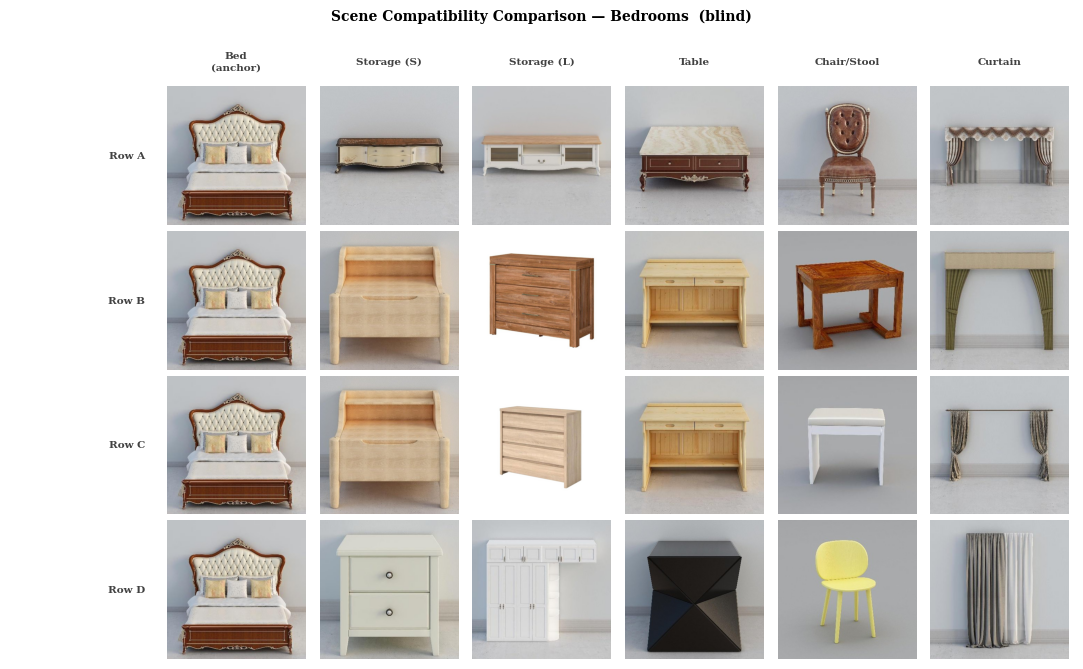

  Saved: llm_judge__bedrooms__seed42.png
  Saved: llm_judge__bedrooms__seed42__blind.png  <- upload this one to the LLM

  Seed 317 row order: {'A': 'Fine-tuned (ours)', 'B': 'ResNet-18 (ImageNet)', 'C': 'Random', 'D': 'EfficientNet-B3 (ImageNet)'}


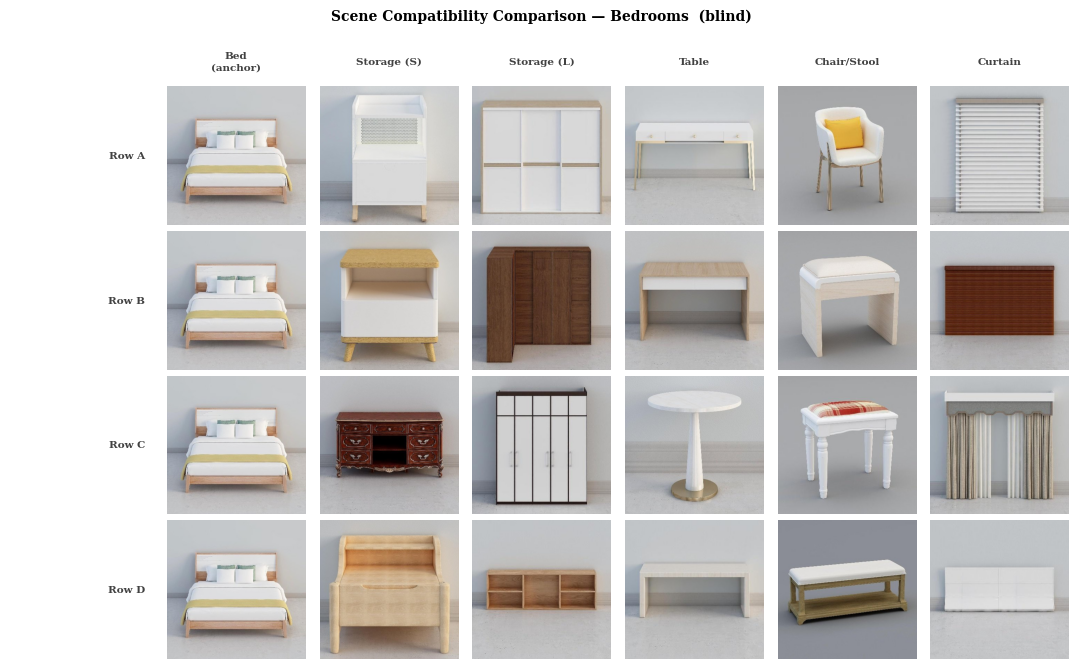

  Saved: llm_judge__bedrooms__seed317.png
  Saved: llm_judge__bedrooms__seed317__blind.png  <- upload this one to the LLM

  Seed 815 row order: {'A': 'EfficientNet-B3 (ImageNet)', 'B': 'Random', 'C': 'ResNet-18 (ImageNet)', 'D': 'Fine-tuned (ours)'}


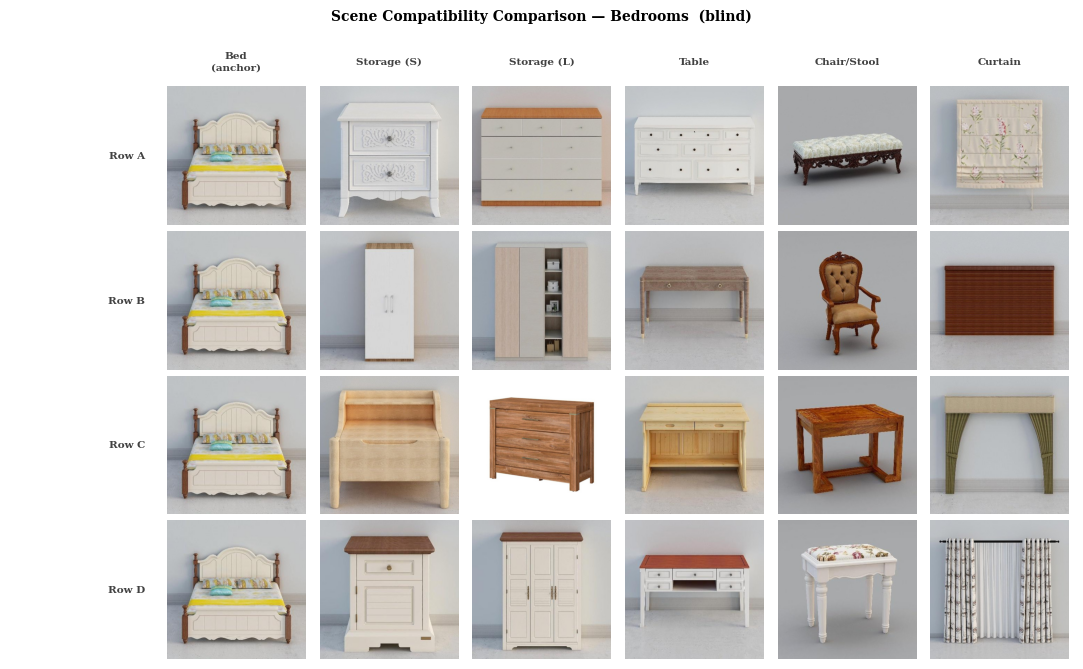

  Saved: llm_judge__bedrooms__seed815.png
  Saved: llm_judge__bedrooms__seed815__blind.png  <- upload this one to the LLM

  Living Rooms

Loading fine-tuned retriever (living_rooms)...
Loading histogram cache...
FurnitureRetriever ready — 2509 items, 6 categories
  chair_stool    : 220 items
  curtain        : 222 items
  large_storage  : 294 items
  small_storage  : 324 items
  sofa           : 822 items
  table          : 627 items

Building ResNet-18 ImageNet baseline (living_rooms)...
Extracting features for 2509 items (living_rooms)...
  2509/2509
  Done — 2509 items, 6 categories

Building EfficientNet-B3 ImageNet baseline (living_rooms)...
Extracting features for 2509 items (living_rooms)...
  2509/2509
  Done — 2509 items, 6 categories

  Seed 42 row order: {'A': 'Fine-tuned (ours)', 'B': 'ResNet-18 (ImageNet)', 'C': 'EfficientNet-B3 (ImageNet)', 'D': 'Random'}


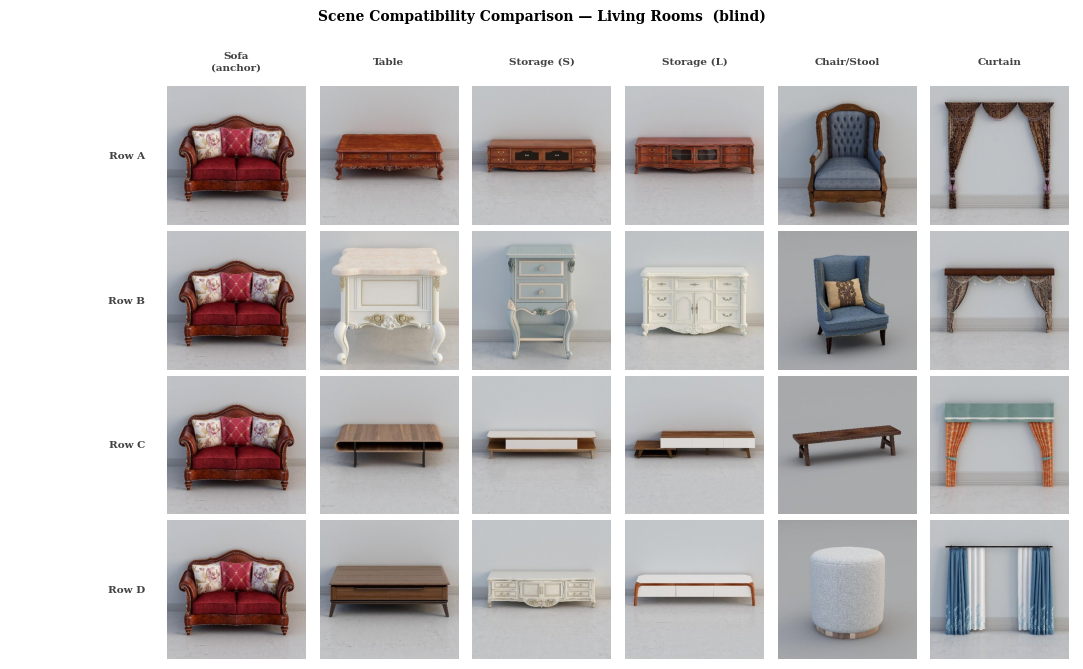

  Saved: llm_judge__living_rooms__seed42.png
  Saved: llm_judge__living_rooms__seed42__blind.png  <- upload this one to the LLM

  Seed 317 row order: {'A': 'Fine-tuned (ours)', 'B': 'ResNet-18 (ImageNet)', 'C': 'Random', 'D': 'EfficientNet-B3 (ImageNet)'}


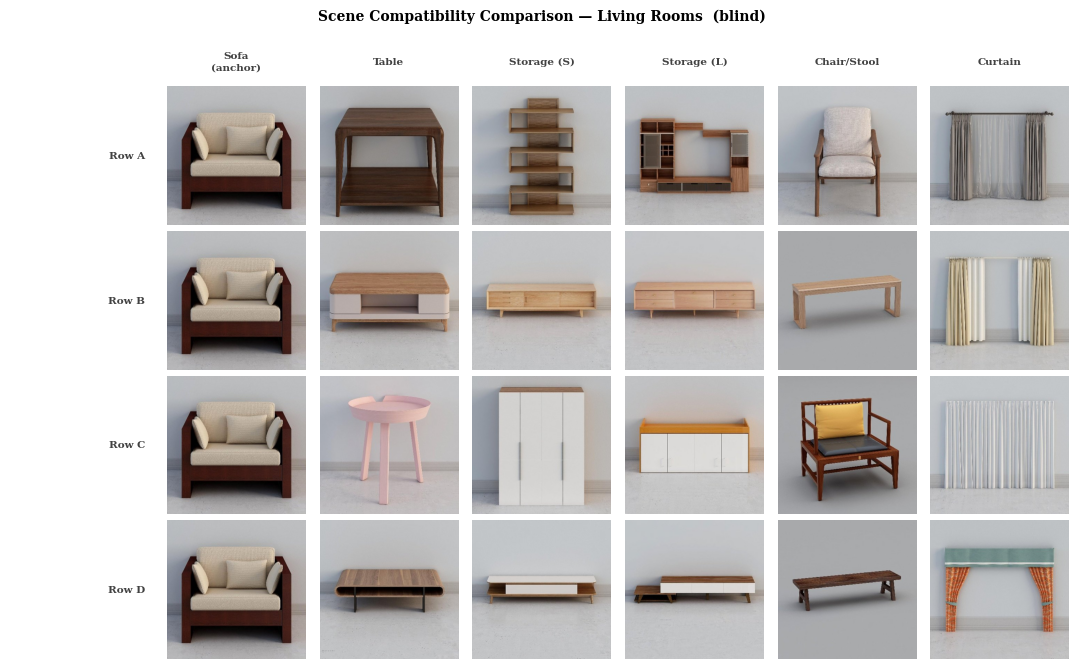

  Saved: llm_judge__living_rooms__seed317.png
  Saved: llm_judge__living_rooms__seed317__blind.png  <- upload this one to the LLM

  Seed 815 row order: {'A': 'EfficientNet-B3 (ImageNet)', 'B': 'Random', 'C': 'ResNet-18 (ImageNet)', 'D': 'Fine-tuned (ours)'}


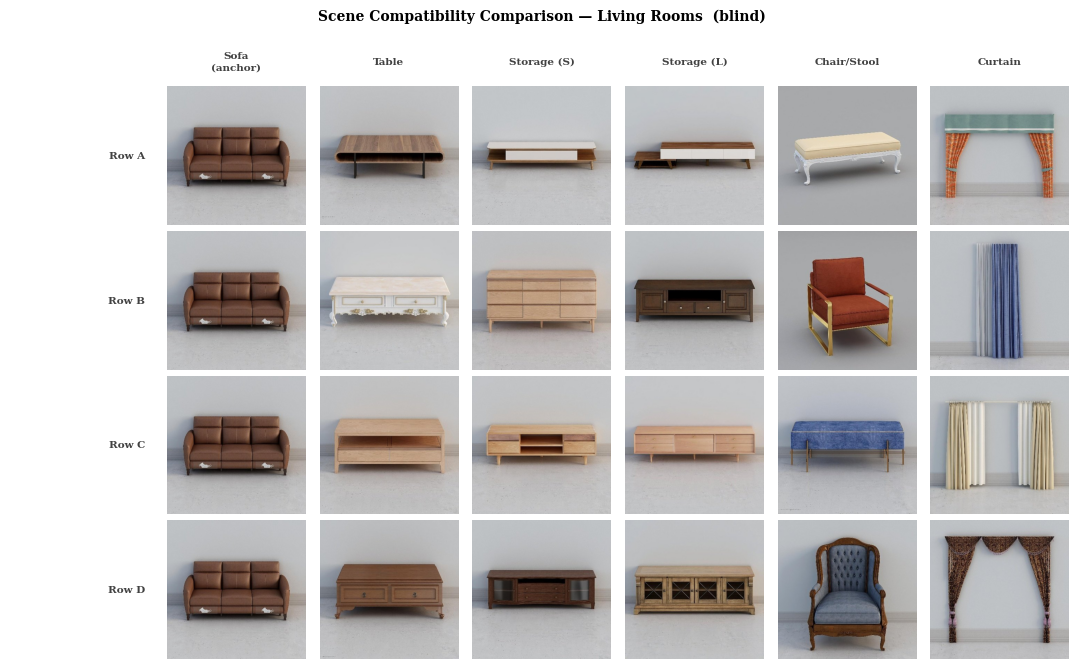

  Saved: llm_judge__living_rooms__seed815.png
  Saved: llm_judge__living_rooms__seed815__blind.png  <- upload this one to the LLM

All figures saved to: d:\Programing\thesis_v2_v3\data\thesis_figures\llm_judge

--- Row mapping summary (use this to decode LLM responses) ---
  bedrooms, seed 42: A=Fine-tuned (ours) | B=ResNet-18 (ImageNet) | C=EfficientNet-B3 (ImageNet) | D=Random
  bedrooms, seed 317: A=Fine-tuned (ours) | B=ResNet-18 (ImageNet) | C=Random | D=EfficientNet-B3 (ImageNet)
  bedrooms, seed 815: A=EfficientNet-B3 (ImageNet) | B=Random | C=ResNet-18 (ImageNet) | D=Fine-tuned (ours)
  living_rooms, seed 42: A=Fine-tuned (ours) | B=ResNet-18 (ImageNet) | C=EfficientNet-B3 (ImageNet) | D=Random
  living_rooms, seed 317: A=Fine-tuned (ours) | B=ResNet-18 (ImageNet) | C=Random | D=EfficientNet-B3 (ImageNet)
  living_rooms, seed 815: A=EfficientNet-B3 (ImageNet) | B=Random | C=ResNet-18 (ImageNet) | D=Fine-tuned (ours)


In [7]:
ROOMS = ["bedrooms", "living_rooms"]

N_SEEDS = 3
SEEDS = [42, 317, 815]
print(f"Using seeds: {SEEDS}  (record these for reproducibility)\n")

# Stores row mapping per (room, seed) for decoding LLM responses
ROW_MAPS = {}

for room in ROOMS:
    print(f"\n{'='*50}")
    print(f"  {ROOM_LABELS[room]}")
    print(f"{'='*50}")
    retrievers = load_retrievers(room)
    method_names = list(retrievers.keys())

    for seed in SEEDS:
        # Use a different seed offset so row shuffle is independent of anchor seed
        random.seed(seed + 9999)
        perm = random.sample(range(len(method_names)), len(method_names))
        shuffled = {method_names[i]: retrievers[method_names[i]] for i in perm}
        row_order = [method_names[i] for i in perm]
        ROW_MAPS[(room, seed)] = row_order

        label_map = {chr(65 + j): row_order[j].replace("\n", " ") for j in range(len(row_order))}
        print(f"\n  Seed {seed} row order: {label_map}")

        # Labeled version — for thesis figure
        fig = make_comparison_figure(room, shuffled, seed=seed, blind=False)
        path = OUT_DIR / f"llm_judge__{room}__seed{seed}.png"
        fig.savefig(path)
        plt.close(fig)

        # Blind version — upload these to the LLM judge
        fig_blind = make_comparison_figure(room, shuffled, seed=seed, blind=True)
        path_blind = OUT_DIR / f"llm_judge__{room}__seed{seed}__blind.png"
        fig_blind.savefig(path_blind)
        plt.show()
        plt.close(fig_blind)

        print(f"  Saved: {path.name}")
        print(f"  Saved: {path_blind.name}  <- upload this one to the LLM")

print(f"\nAll figures saved to: {OUT_DIR}")
print("\n--- Row mapping summary (use this to decode LLM responses) ---")
for (room, seed), order in ROW_MAPS.items():
    mapping = " | ".join(f"{chr(65+j)}={order[j].replace(chr(10),' ')}" for j in range(len(order)))
    print(f"  {room}, seed {seed}: {mapping}")